# 06 — Optimizers from Scratch

## Goal

Automatic differentiation tells us how the loss changes with respect
to each trainable parameter:

$$
\nabla_\theta L.
$$

However, gradients alone do not update the model.

An optimizer defines a rule for transforming the current parameters

$$
\theta_t
$$

into new parameters

$$
\theta_{t+1}.
$$

The simplest update rule is gradient descent:

$$
\theta_{t+1}
=
\theta_t
-
\eta \nabla_\theta L,
$$

where

$$
\eta
$$

is the learning rate.

This lesson implements several optimization algorithms from scratch in
order to understand how gradients are converted into parameter updates.

## 1. Manual Gradient Descent

Consider the simple objective

$$
L(w) = (w-3)^2.
$$

The minimum occurs at

$$
w=3.
$$

Its derivative is

$$
\frac{dL}{dw}
=
2(w-3).
$$

If

$$
w>3,
$$

the gradient is positive, so gradient descent decreases $w$.

If

$$
w<3,
$$

the gradient is negative, so gradient descent increases $w$.

The negative gradient therefore points locally toward lower loss.

In [1]:
import torch

w: torch.Tensor = torch.tensor(8.0, requires_grad=True)

loss: torch.Tensor = (w - 3.0) ** 2
loss.backward()

print("w", w.item())
print("loss", loss.item())
print("gradient", w.grad.item())


w 8.0
loss 25.0
gradient 10.0


In [2]:
learning_rate: float = 0.1

with torch.no_grad():
    w -= learning_rate * w.grad

print("updated w:", w.item())


updated w: 7.0


### Why Update Parameters Under `torch.no_grad()`?

The optimizer update is not part of the model's forward computation.

For example,

$$
w \leftarrow w - \eta \nabla_w L
$$

changes the parameter value, but we do not want autograd to construct
another computation graph describing how the optimizer modified the
parameter.

Parameter updates are therefore performed without gradient tracking.

In PyTorch, this can be expressed using:

`torch.no_grad()`

The model computation remains differentiable, while the optimizer
update itself is treated as an external state change.


In [3]:
new_loss: torch.Tensor = (w - 3.0) ** 2

print("new w:", w.item())
print("new loss:", new_loss.item())

new w: 7.0
new loss: 16.0


In [4]:
print(w.grad)

tensor(10.)


In [5]:
new_loss.backward()

print("accumulated gradient:", w.grad.item())

accumulated gradient: 18.0


## 2. Gradient Accumulation

PyTorch accumulates gradients into `.grad` rather than replacing them.

If a parameter already contains

$$
g_{\text{old}}
$$

and a new backward pass produces

$$
g_{\text{new}},
$$

the stored gradient becomes

$$
g_{\text{old}} + g_{\text{new}}.
$$

This behavior is useful when intentionally accumulating gradients across
multiple computations.

For ordinary optimization steps, however, gradients are usually cleared
before computing the next update.

In [6]:
w.grad = None

loss = (w - 3.0) ** 2
loss.backward()

print(w.grad)

tensor(8.)


In [8]:
# training loop

w: torch.Tensor = torch.tensor(8.0, requires_grad=True)

learning_rate: float = 0.1

for step in range(10):
    loss: torch.Tensor = (w - 3.0) ** 2

    w.grad = None
    loss.backward()

    with torch.no_grad():
        w -= learning_rate * w.grad

    print(f"step={step:2d} w={w.item():.4f} loss={loss.item():.4f}")

step= 0 w=7.0000 loss=25.0000
step= 1 w=6.2000 loss=16.0000
step= 2 w=5.5600 loss=10.2400
step= 3 w=5.0480 loss=6.5536
step= 4 w=4.6384 loss=4.1943
step= 5 w=4.3107 loss=2.6844
step= 6 w=4.0486 loss=1.7180
step= 7 w=3.8389 loss=1.0995
step= 8 w=3.6711 loss=0.7037
step= 9 w=3.5369 loss=0.4504


In [9]:
def run_gradient_descent(
    initial_w: float,
    learning_rate: float,
    steps: int,
) -> list[float]:
    w: torch.Tensor = torch.tensor(
        initial_w,
        requires_grad=True,
    )

    history: list[float] = []

    for _ in range(steps):
        loss: torch.Tensor = (w - 3.0) ** 2

        w.grad = None
        loss.backward()

        with torch.no_grad():
            w -= learning_rate * w.grad

        history.append(w.item())

    return history

In [10]:
print(
    "lr=0.01:",
    run_gradient_descent(
        initial_w=8.0,
        learning_rate=0.01,
        steps=10,
    ),
)

print(
    "lr=0.1:",
    run_gradient_descent(
        initial_w=8.0,
        learning_rate=0.1,
        steps=10,
    ),
)

print(
    "lr=1.1:",
    run_gradient_descent(
        initial_w=8.0,
        learning_rate=1.1,
        steps=10,
    ),
)

lr=0.01: [7.900000095367432, 7.802000045776367, 7.705960273742676, 7.611841201782227, 7.519604206085205, 7.4292120933532715, 7.340627670288086, 7.253815174102783, 7.168738842010498, 7.085363864898682]
lr=0.1: [7.0, 6.199999809265137, 5.559999942779541, 5.047999858856201, 4.638400077819824, 4.310719966888428, 4.0485758781433105, 3.8388607501983643, 3.671088695526123, 3.5368709564208984]
lr=1.1: [-3.0, 10.200000762939453, -5.64000129699707, 13.368001937866211, -9.44160270690918, 17.92992401123047, -14.915908813476562, 24.49909210205078, -22.798912048339844, 33.95869445800781]


## 3. A Minimal SGD Optimizer

An optimizer does not need to know how the model produced its loss.

After backpropagation, each trainable parameter contains a gradient:

$$
\nabla_{\theta_i} L.
$$

For vanilla stochastic gradient descent, every parameter is updated
independently using

$$
\theta_i
\leftarrow
\theta_i
-
\eta \nabla_{\theta_i} L.
$$

The optimizer therefore only needs:

1. a collection of trainable parameters,
2. a learning rate,
3. a method for clearing old gradients,
4. a method for applying the update rule.

This creates an important separation of responsibilities:

<pre>
model        → defines the forward computation
autograd     → computes gradients
optimizer    → updates parameters
</pre>

In [12]:
class SGD:
    def __init__(
        self, parameters: list[torch.Tensor], learning_rate: float
    ) -> None:

        if learning_rate <= 0.0:
            raise ValueError("learning rate must be positive")

        self.parameters: list[torch.Tensor] = parameters
        self.learning_rate: float = learning_rate

    def zero_grad(self) -> None:
        for parameter in self.parameters:
            parameter.grad = None

    def step(self) -> None:
        with torch.no_grad():
            for parameter in self.parameters:
                if parameter.grad is None:
                    continue

                parameter -= self.learning_rate * parameter.grad


w: torch.Tensor = torch.tensor(
    8.0,
    requires_grad=True,
)

optimizer = SGD(
    parameters=[w],
    learning_rate=0.1,
)


for step in range(10):
    loss: torch.Tensor = (w - 3.0) ** 2

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    print(f"step={step:2d} w={w.item():.4f} loss={loss.item():.4f}")

step= 0 w=7.0000 loss=25.0000
step= 1 w=6.2000 loss=16.0000
step= 2 w=5.5600 loss=10.2400
step= 3 w=5.0480 loss=6.5536
step= 4 w=4.6384 loss=4.1943
step= 5 w=4.3107 loss=2.6844
step= 6 w=4.0486 loss=1.7180
step= 7 w=3.8389 loss=1.0995
step= 8 w=3.6711 loss=0.7037
step= 9 w=3.5369 loss=0.4504


In [13]:
a: torch.Tensor = torch.tensor(
    8.0,
    requires_grad=True,
)

b: torch.Tensor = torch.tensor(
    4.0,
    requires_grad=True,
)

optimizer = SGD(
    parameters=[a, b],
    learning_rate=0.1,
)

for step in range(20):
    loss: torch.Tensor = (a - 2.0) ** 2 + (b + 3.0) ** 2

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(
        f"step={step:2d} "
        f"a={a.item():.3f} "
        f"b={b.item():.3f} "
        f"loss={loss.item():.3f}"
    )

step= 0 a=6.800 b=2.600 loss=85.000
step= 1 a=5.840 b=1.480 loss=54.400
step= 2 a=5.072 b=0.584 loss=34.816
step= 3 a=4.458 b=-0.133 loss=22.282
step= 4 a=3.966 b=-0.706 loss=14.261
step= 5 a=3.573 b=-1.165 loss=9.127
step= 6 a=3.258 b=-1.532 loss=5.841
step= 7 a=3.007 b=-1.826 loss=3.738
step= 8 a=2.805 b=-2.060 loss=2.393
step= 9 a=2.644 b=-2.248 loss=1.531
step=10 a=2.515 b=-2.399 loss=0.980
step=11 a=2.412 b=-2.519 loss=0.627
step=12 a=2.330 b=-2.615 loss=0.401
step=13 a=2.264 b=-2.692 loss=0.257
step=14 a=2.211 b=-2.754 loss=0.164
step=15 a=2.169 b=-2.803 loss=0.105
step=16 a=2.135 b=-2.842 loss=0.067
step=17 a=2.108 b=-2.874 loss=0.043
step=18 a=2.086 b=-2.899 loss=0.028
step=19 a=2.069 b=-2.919 loss=0.018


### Optimizer Interface

The optimizer operates on parameters through a very small interface.

It does not need to understand the architecture of the model.

A parameter only needs to provide:

- its current value,
- its gradient.

This allows the same optimizer to update parameters belonging to
embeddings, linear layers, attention modules, or an entire Transformer.

## 4. Momentum

Vanilla SGD updates parameters using only the current gradient:

$$
\theta_{t+1}
=
\theta_t
-
\eta g_t,
$$

where

$$
g_t = \nabla_\theta L_t.
$$

Momentum introduces an additional state variable that accumulates
gradient directions over time.

We define a momentum buffer

$$
v_t
=
\beta v_{t-1}
+
g_t,
$$

where

$$
0 \leq \beta < 1.
$$

The parameter update becomes

$$
\theta_{t+1}
=
\theta_t
-
\eta v_t.
$$

The optimizer therefore remembers previous gradient directions.

If gradients repeatedly point in a similar direction, their
contributions accumulate.

If gradients frequently change sign, previous and current contributions
partially cancel.

Unlike vanilla SGD, momentum is therefore a **stateful optimizer**:
every trainable parameter needs its own momentum buffer.

In [14]:
class MomentumSGD:
    def __init__(
        self,
        parameters: list[torch.Tensor],
        learning_rate: float,
        momentum: float = 0.9,
    ) -> None:
        if learning_rate <= 0.0:
            raise ValueError("learning rate must be positive")

        if not 0.0 <= momentum < 1.0:
            raise ValueError("mementum must be in [0,1)")

        self.parameters: list[torch.tensor] = parameters
        self.learning_rate: float = learning_rate
        self.momentum = momentum

        self.buffers: list[torch.Tensor] = [
            torch.zeros_like(parameter) for parameter in parameters
        ]

    def zero_grad(self) -> None:
        for parameter in self.parameters:
            parameter.grad = None

    def step(self) -> None:
        with torch.no_grad():
            for parameter, buffer in zip(
                self.parameters, self.buffers, strict=True
            ):
                if parameter.grad is None:
                    continue

                # in-place operation, we want to maintain the same op state object
                buffer.mul_(self.momentum)
                buffer.add_(parameter.grad)

                parameter -= self.learning_rate * buffer


w: torch.Tensor = torch.tensor(
    8.0,
    requires_grad=True,
)

optimizer = MomentumSGD(
    parameters=[w],
    learning_rate=0.1,
    momentum=0.9,
)

for step in range(10):
    loss: torch.Tensor = (w - 3.0) ** 2

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(
        f"step={step:2d} "
        f"w={w.item():.4f} "
        f"loss={loss.item():.4f} "
        f"buffer={optimizer.buffers[0].item():.4f}"
    )

step= 0 w=7.0000 loss=25.0000 buffer=10.0000
step= 1 w=5.3000 loss=16.0000 buffer=17.0000
step= 2 w=3.3100 loss=5.2900 buffer=19.9000
step= 3 w=1.4570 loss=0.0961 buffer=18.5300
step= 4 w=0.0979 loss=2.3808 buffer=13.5910
step= 5 w=-0.5449 loss=8.4222 buffer=6.4277
step= 6 w=-0.4144 loss=12.5661 buffer=-1.3048
step= 7 w=0.3859 loss=11.6581 buffer=-8.0031
step= 8 w=1.6290 loss=6.8334 buffer=-12.4310
step= 9 w=3.0220 loss=1.8796 buffer=-13.9298


### Optimization in Different Directions

Consider

$$
L(x,y)=x^2+10y^2.
$$

The curvature is much larger in the $y$ direction than in the $x$
direction.

The gradients are

$$
\frac{\partial L}{\partial x}=2x,
$$

and

$$
\frac{\partial L}{\partial y}=20y.
$$

A single learning rate must therefore operate across two directions with
very different gradient scales.

This can cause vanilla SGD to oscillate strongly in one direction while
making slower progress in another.

Momentum can accumulate consistent movement while partially cancelling
rapidly changing gradient directions.

## 5. Adam

Momentum remembers the historical direction of the gradient, but it
uses the same learning-rate scale for every parameter.

Adam adds a second form of memory that tracks the historical magnitude
of squared gradients.

For the current gradient

$$
g_t = \nabla_\theta L_t,
$$

Adam maintains two moving averages.

### First moment

$$
m_t
=
\beta_1 m_{t-1}
+
(1-\beta_1)g_t.
$$

This tracks the recent average direction of the gradient.

### Second raw moment

$$
v_t
=
\beta_2 v_{t-1}
+
(1-\beta_2)g_t^2.
$$

This tracks the recent average squared magnitude of the gradient.

The word "raw" is important: $v_t$ is not the statistical variance.
It is an exponential moving average of squared gradients.

Adam then uses approximately

$$
\frac{m_t}{\sqrt{v_t}}
$$

as a normalized update direction.

Parameters with historically large gradients receive smaller effective
steps, while parameters with smaller gradients can receive relatively
larger steps.

## 6. Bias Correction

Adam initializes both moment estimates at zero:

$$
m_0 = 0,
\qquad
v_0 = 0.
$$

Because the exponential moving averages start from zero, their early
values are biased toward zero.

For example, at the first optimization step,

$$
m_1
=
(1-\beta_1)g_1.
$$

With

$$
\beta_1=0.9,
$$

this gives only

$$
0.1g_1.
$$

Similarly,

$$
v_1
=
(1-\beta_2)g_1^2.
$$

With

$$
\beta_2=0.999,
$$

this is only

$$
0.001g_1^2.
$$

Adam therefore corrects this initialization bias:

$$
\hat m_t
=
\frac{m_t}
{1-\beta_1^t}
$$

and

$$
\hat v_t
=
\frac{v_t}
{1-\beta_2^t}.
$$

As $t$ becomes large, both correction factors approach one, so the
correction matters mainly during early optimization steps.

In [15]:
class Adam:
    def __init__(
        self,
        parameters: list[torch.Tensor],
        learning_rate: float = 1e-3,
        beta1: float = 0.9,
        beta2: float = 0.999,
        epsilon: float = 1e-8,
    ) -> None:

        self.parameters = parameters
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon

        self.first_moments: list[torch.Tensor] = [
            torch.zeros_like(parameter) for parameter in parameters
        ]

        self.second_moments: list[torch.Tensor] = [
            torch.zeros_like(parameter) for parameter in parameters
        ]

        self.steps: list[int] = [0 for _ in parameters]

    def zero_grad(self) -> None:
        for parameter in self.parameters:
            parameter.grad = None

    def step(self) -> None:
        with torch.no_grad():
            for index, parameter in enumerate(self.parameters):
                if parameter.grad is None:
                    continue

                self.steps[index] += 1
                step: int = self.steps[index]

                gradient: torch.Tensor = parameter.grad

                first_moment: torch.Tensor = self.first_moments[index]
                second_moment: torch.Tensor = self.second_moments[index]

                first_moment.mul_(self.beta1)
                first_moment.add_(gradient, alpha=1.0 - self.beta1)

                second_moment.mul_(self.beta2)
                second_moment.add_(gradient.square(), alpha=1.0 - self.beta2)

                first_corrected: torch.Tensor = first_moment / (
                    1.0 - self.beta2**step
                )
                second_corrected: torch.Tensor = second_moment / (
                    1.0 - self.beta2**step
                )

                update: torch.Tensor = first_corrected / (
                    torch.sqrt(second_corrected) + self.epsilon
                )
                parameter -= self.learning_rate * update


In [16]:
w: torch.Tensor = torch.tensor(
    8.0,
    requires_grad=True,
)

optimizer = Adam(
    parameters=[w],
    learning_rate=0.1,
)

for step in range(20):
    loss: torch.Tensor = (w - 3.0) ** 2

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(
        f"step={step:2d} "
        f"w={w.item():.4f} "
        f"loss={loss.item():.4f} "
        f"m={optimizer.first_moments[0].item():.4f} "
        f"v={optimizer.second_moments[0].item():.4f}"
    )

step= 0 w=-2.0000 loss=25.0000 m=1.0000 v=0.1000
step= 1 w=-1.4997 loss=25.0000 m=-0.1000 v=0.1999
step= 2 w=1.9134 loss=20.2477 m=-0.9899 v=0.2807
step= 3 w=5.1975 loss=1.1807 m=-1.1083 v=0.2851
step= 4 w=6.6297 loss=4.8291 m=-0.5579 v=0.3042
step= 5 w=6.1452 loss=13.1744 m=0.2238 v=0.3566
step= 6 w=4.5651 loss=9.8925 m=0.8305 v=0.3958
step= 7 w=2.6993 loss=2.4495 m=1.0604 v=0.4052
step= 8 w=1.2154 loss=0.0904 m=0.8942 v=0.4051
step= 9 w=0.5206 loss=3.1849 m=0.4479 v=0.4175
step=10 w=0.6541 loss=6.1474 m=-0.0928 v=0.4416
step=11 w=1.3974 loss=5.5034 m=-0.5527 v=0.4632
step=12 w=2.4436 loss=2.5683 m=-0.8179 v=0.4730
step=13 w=3.4875 loss=0.3096 m=-0.8474 v=0.4738
step=14 w=4.2789 loss=0.2377 m=-0.6652 v=0.4743
step=15 w=4.6715 loss=1.6356 m=-0.3429 v=0.4803
step=16 w=4.6433 loss=2.7939 m=0.0257 v=0.4910
step=17 w=4.2713 loss=2.7003 m=0.3518 v=0.5013
step=18 w=3.6872 loss=1.6163 m=0.5709 v=0.5073
step=19 w=3.0385 loss=0.4723 m=0.6512 v=0.5087


In [17]:
w: torch.Tensor = torch.tensor(
    8.0,
    requires_grad=True,
)

optimizer = Adam(
    parameters=[w],
    learning_rate=0.1,
)

loss: torch.Tensor = (w - 3.0) ** 2

optimizer.zero_grad()
loss.backward()

print("gradient:", w.grad.item())

optimizer.step()

print("m:", optimizer.first_moments[0].item())
print("v:", optimizer.second_moments[0].item())
print("new w:", w.item())

gradient: 10.0
m: 1.0
v: 0.10000000149011612
new w: -1.9999990463256836


## 7. Weight Decay and AdamW

Weight decay encourages parameters to remain small during training.

For ordinary SGD, weight decay and L2 regularization can produce the
same parameter update.

However, this equivalence breaks for adaptive optimizers such as Adam.

AdamW therefore **decouples weight decay from the gradient-based Adam
update**.

Instead of adding the decay term to the gradient before Adam computes
its moments, AdamW applies parameter shrinkage separately.

### SGD: L2 Regularization and Weight Decay

Suppose the regularized objective is

$$
L_{\text{reg}}(\theta)
=
L(\theta)
+
\frac{\lambda}{2}\theta^2.
$$

Its gradient is

$$
\nabla_\theta L_{\text{reg}}
=
g+\lambda\theta,
$$

where

$$
g=\nabla_\theta L.
$$

SGD therefore updates the parameter as

$$
\theta_{t+1}
=
\theta_t
-
\eta(g+\lambda\theta_t).
$$

Rearranging,

$$
\theta_{t+1}
=
(1-\eta\lambda)\theta_t
-
\eta g.
$$

The first term shrinks the parameter directly, while the second term is
the ordinary gradient update.

For vanilla SGD, adding an L2 penalty to the gradient is therefore
equivalent to multiplicative weight decay.

### SGD: L2 Regularization and Weight Decay

Suppose the regularized objective is

$$
L_{\text{reg}}(\theta)
=
L(\theta)
+
\frac{\lambda}{2}\theta^2.
$$

Its gradient is

$$
\nabla_\theta L_{\text{reg}}
=
g+\lambda\theta,
$$

where

$$
g=\nabla_\theta L.
$$

SGD therefore updates the parameter as

$$
\theta_{t+1}
=
\theta_t
-
\eta(g+\lambda\theta_t).
$$

Rearranging,

$$
\theta_{t+1}
=
(1-\eta\lambda)\theta_t
-
\eta g.
$$

The first term shrinks the parameter directly, while the second term is
the ordinary gradient update.

For vanilla SGD, adding an L2 penalty to the gradient is therefore
equivalent to multiplicative weight decay.

In [18]:
class AdamW:
    def __init__(
        self,
        parameters: list[torch.Tensor],
        learning_rate: float = 1e-3,
        beta1: float = 0.9,
        beta2: float = 0.999,
        epsilon: float = 1e-8,
        weight_decay: float = 0.01,
    ) -> None:
        if learning_rate <= 0.0:
            raise ValueError("learning_rate must be positive.")

        if not 0.0 <= beta1 < 1.0:
            raise ValueError("beta1 must be in [0, 1).")

        if not 0.0 <= beta2 < 1.0:
            raise ValueError("beta2 must be in [0, 1).")

        if weight_decay < 0.0:
            raise ValueError("weight_decay must be non-negative.")

        self.parameters: list[torch.Tensor] = parameters
        self.learning_rate: float = learning_rate
        self.beta1: float = beta1
        self.beta2: float = beta2
        self.epsilon: float = epsilon
        self.weight_decay: float = weight_decay

        self.first_moments: list[torch.Tensor] = [
            torch.zeros_like(parameter) for parameter in parameters
        ]

        self.second_moments: list[torch.Tensor] = [
            torch.zeros_like(parameter) for parameter in parameters
        ]

        self.steps: list[int] = [0 for _ in parameters]

    def zero_grad(self) -> None:
        for parameter in self.parameters:
            parameter.grad = None

    def step(self) -> None:
        with torch.no_grad():
            for index, parameter in enumerate(self.parameters):
                if parameter.grad is None:
                    continue

                self.steps[index] += 1
                step: int = self.steps[index]

                gradient: torch.Tensor = parameter.grad

                first_moment: torch.Tensor = self.first_moments[index]

                second_moment: torch.Tensor = self.second_moments[index]

                first_moment.mul_(self.beta1)
                first_moment.add_(
                    gradient,
                    alpha=1.0 - self.beta1,
                )

                second_moment.mul_(self.beta2)
                second_moment.add_(
                    gradient.square(),
                    alpha=1.0 - self.beta2,
                )

                first_corrected: torch.Tensor = first_moment / (
                    1.0 - self.beta1**step
                )

                second_corrected: torch.Tensor = second_moment / (
                    1.0 - self.beta2**step
                )

                update: torch.Tensor = first_corrected / (
                    torch.sqrt(second_corrected) + self.epsilon
                )

                # Decoupled weight decay
                parameter.mul_(1.0 - self.learning_rate * self.weight_decay)

                # Adam update
                parameter.add_(
                    update,
                    alpha=-self.learning_rate,
                )

In [19]:
initial_value: torch.Tensor = torch.tensor(
    [2.0, -3.0],
)

manual_parameter: torch.Tensor = initial_value.clone().requires_grad_(True)

torch_parameter: torch.Tensor = initial_value.clone().requires_grad_(True)

In [21]:
manual_optimizer = AdamW(
    parameters=[manual_parameter],
    learning_rate=0.01,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    weight_decay=0.01,
)

torch_optimizer = torch.optim.AdamW(
    [torch_parameter],
    lr=0.01,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=0.01,
)

In [22]:
for _ in range(10):
    manual_loss: torch.Tensor = (manual_parameter**2).sum()

    torch_loss: torch.Tensor = (torch_parameter**2).sum()

    manual_optimizer.zero_grad()
    torch_optimizer.zero_grad()

    manual_loss.backward()
    torch_loss.backward()

    manual_optimizer.step()
    torch_optimizer.step()

In [24]:
print("manual:", manual_parameter)
print("PyTorch:", torch_parameter)

print(
    torch.allclose(
        manual_parameter,
        torch_parameter,
        atol=1e-6,
    )
)

manual: tensor([ 1.7975, -2.7950], requires_grad=True)
PyTorch: tensor([ 1.7975, -2.7950], requires_grad=True)
True


## 8. Learning-Rate Scheduling

An optimizer defines how parameters are updated given a learning rate.

For example, AdamW performs an update of the form

$$
\theta_{t+1}
=
(1-\eta_t\lambda)\theta_t
-
\eta_t
\frac{\hat m_t}
{\sqrt{\hat v_t}+\epsilon}.
$$

The learning rate

$$
\eta_t
$$

does not need to remain constant during training.

A **learning-rate scheduler** defines how the learning rate changes as a
function of the training step.

This separates two responsibilities:

<pre>
optimizer
    → how gradients and optimizer state produce an update

scheduler
    → how large the learning rate should be at each step
</pre>

A common language-model training schedule combines:

1. linear warmup,
2. cosine decay.

### Linear Warmup

At the beginning of training, model parameters and optimizer states are
still poorly calibrated.

Using the full learning rate immediately may produce unnecessarily large
updates.

During linear warmup, the learning rate increases gradually from a small
value to a peak learning rate.

If the warmup lasts for $W$ steps, then for

$$
1 \leq t \leq W,
$$

we define

$$
\eta_t
=
\eta_{\max}
\frac{t}{W}.
$$

Therefore,

$$
\eta_W = \eta_{\max}.
$$

In [25]:
def linear_warmup(
    step: int, warmup_steps: int, peak_learning_rate: float
) -> float:
    if warmup_steps <= 0:
        raise ValueError("warmup steps must be positive")

    if not 1 <= step <= warmup_steps:
        raise ValueError("step must be inside the warmup interval")

    progress: float = step / warmup_steps

    return peak_learning_rate * progress


for step in range(1, 11):
    learning_rate: float = linear_warmup(
        step=step,
        warmup_steps=10,
        peak_learning_rate=3e-4,
    )

    print(f"step={step:2d} lr={learning_rate:.6f}")

step= 1 lr=0.000030
step= 2 lr=0.000060
step= 3 lr=0.000090
step= 4 lr=0.000120
step= 5 lr=0.000150
step= 6 lr=0.000180
step= 7 lr=0.000210
step= 8 lr=0.000240
step= 9 lr=0.000270
step=10 lr=0.000300


### Cosine Decay

After warmup, the learning rate can gradually decrease.

A cosine schedule defines

$$
\eta_t
=
\eta_{\min}
+
\frac{1}{2}
(\eta_{\max}-\eta_{\min})
\left(
1+\cos(\pi p_t)
\right),
$$

where

$$
p_t \in [0,1]
$$

represents the fraction of the decay phase that has completed.

At the beginning of the decay phase,

$$
p_t=0,
$$

so

$$
\eta_t=\eta_{\max}.
$$

At the final training step,

$$
p_t=1,
$$

so

$$
\eta_t=\eta_{\min}.
$$

The cosine curve decreases slowly at first and near the end, while
changing more rapidly in the middle.

In [27]:
import math


def cosine_decay(
    progress: float, peak_learning_rate: float, minimum_learning_rate: float
) -> float:
    if not 0.0 <= progress <= 1.0:
        raise ValueError("progress must be between 0 and 1")

    cosine: float = 0.5 * 1.0 + math.cos(math.pi * progress)

    return (
        minimum_learning_rate
        + (peak_learning_rate - minimum_learning_rate) * cosine
    )


for index in range(11):
    progress: float = index / 10

    learning_rate: float = cosine_decay(
        progress=progress,
        peak_learning_rate=3e-4,
        minimum_learning_rate=3e-5,
    )

    print(f"progress={progress:.1f} lr={learning_rate:.7f}")

progress=0.0 lr=0.0004350
progress=0.1 lr=0.0004218
progress=0.2 lr=0.0003834
progress=0.3 lr=0.0003237
progress=0.4 lr=0.0002484
progress=0.5 lr=0.0001650
progress=0.6 lr=0.0000816
progress=0.7 lr=0.0000063
progress=0.8 lr=-0.0000534
progress=0.9 lr=-0.0000918
progress=1.0 lr=-0.0001050


## 9. Linear Warmup Followed by Cosine Decay

We now combine both phases.

Let

$$
N
$$

be the total number of optimization steps and

$$
W
$$

the number of warmup steps.

For

$$
1 \leq t \leq W,
$$

the learning rate increases linearly:

$$
\eta_t
=
\eta_{\max}
\frac{t}{W}.
$$

After warmup, define the decay progress as

$$
p_t
=
\frac{t-W}{N-W}.
$$

The cosine phase then uses

$$
\eta_t
=
\eta_{\min}
+
\frac{1}{2}
(\eta_{\max}-\eta_{\min})
\left(
1+\cos(\pi p_t)
\right).
$$

This produces the trajectory

<pre>
learning rate

      /\
     /  \
    /    \
   /      \
  /        \__
warmup      cosine decay
</pre>

In [28]:
def warmup_cosine_learning_rate(
    step: int,
    total_steps: int,
    warmup_steps: int,
    peak_learning_rate: float,
    minimum_learning_rate: float,
) -> float:
    if not 1 <= step <= total_steps:
        raise ValueError("step must be between 1 and total_steps.")

    if not 0 <= warmup_steps < total_steps:
        raise ValueError("warmup_steps must be in [0, total_steps).")

    if step <= warmup_steps:
        if warmup_steps == 0:
            return peak_learning_rate

        warmup_progress: float = step / warmup_steps

        return peak_learning_rate * warmup_progress

    decay_steps: int = total_steps - warmup_steps

    decay_step: int = step - warmup_steps

    decay_progress: float = decay_step / decay_steps

    return cosine_decay(
        progress=decay_progress,
        peak_learning_rate=peak_learning_rate,
        minimum_learning_rate=minimum_learning_rate,
    )

In [32]:
total_steps: int = 100
warmup_steps: int = 10

learning_rates: list[float] = []

for step in range(1, total_steps + 1):
    learning_rate: float = warmup_cosine_learning_rate(
        step=step,
        total_steps=total_steps,
        warmup_steps=warmup_steps,
        peak_learning_rate=3e-4,
        minimum_learning_rate=3e-5,
    )

    learning_rates.append(learning_rate)

for step in [1, 5, 10, 11, 50, 100]:
    print(
        step,
        learning_rates[step - 1],
    )

1 2.9999999999999997e-05
5 0.00015
10 0.0003
11 0.00043483552329515586
50 0.00021188500797007117
100 -0.00010499999999999998


Matplotlib is building the font cache; this may take a moment.


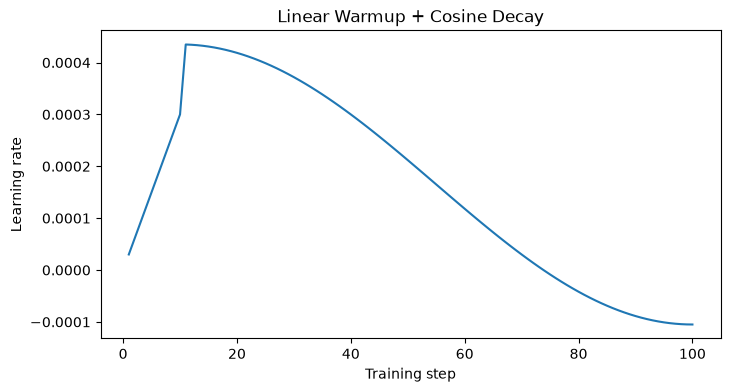

In [34]:
import matplotlib.pyplot as plt


steps: list[int] = list(range(1, total_steps + 1))

plt.figure(figsize=(8, 4))

plt.plot(
    steps,
    learning_rates,
)

plt.xlabel("Training step")
plt.ylabel("Learning rate")
plt.title("Linear Warmup + Cosine Decay")

plt.show()

## Takeaways

- Autograd computes gradients; optimizers use them to update parameters.

- Vanilla SGD applies

  $$
  \theta_{t+1}
  =
  \theta_t-\eta g_t.
  $$

- Momentum introduces a persistent buffer that stores a decayed history
  of previous gradients.

- Adam maintains two optimizer states:

  $$
  m_t
  $$

  for the first moment and

  $$
  v_t
  $$

  for the second raw moment.

- Adam uses bias correction because its moving averages are initialized
  at zero.

- Dividing by

  $$
  \sqrt{\hat v_t}
  $$

  adapts the update scale independently for different parameters.

- AdamW decouples weight decay from Adam's moment estimates.

- Optimizer state is required when resuming training but is not needed
  for ordinary inference.

- A learning-rate scheduler is separate from the optimizer.

- Linear warmup gradually increases the learning rate at the beginning
  of training.

- Cosine decay gradually reduces the learning rate later in training.

- Model parameters, optimizer state, and scheduler state are distinct
  pieces of training state.